## <b> <span style='color:#e61227'>|</span> Convolutional Neural Network for Diabetic Retinopathy Detection (Pytorch) </b> 

In [1]:
!pip install -q torchsummary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
import copy
import os
import torch
from PIL import Image
from torch.utils.data import Dataset
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn
from torchvision import utils
from torchvision.datasets import ImageFolder
from torchsummary import summary
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc, RocCurveDisplay
)
import itertools
from tqdm import tqdm                  # <-- fixed: plain tqdm instead of tqdm.notebook (fixes the HBoxModel widget error)
from torch import optim
import warnings
warnings.filterwarnings('ignore')
import numpy as np

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
from IPython.core.display import display, HTML, Javascript

color_map = ['#FFFFFF','#FF5733']

prompt = color_map[-1]
main_color = color_map[0]
strong_main_color = color_map[1]
custom_colors = [strong_main_color, main_color]

css_file = '''
div #notebook {
background-color: white;
line-height: 20px;
}

#notebook-container {
%s
margin-top: 2em;
padding-top: 2em;
border-top: 4px solid %s;
-webkit-box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
    box-shadow: 0px 0px 8px 2px rgba(224, 212, 226, 0.5);
}

div .input {
margin-bottom: 1em;
}

.rendered_html h1, .rendered_html h2, .rendered_html h3, .rendered_html h4, .rendered_html h5, .rendered_html h6 {
color: %s;
font-weight: 600;
}

div.input_area {
border: none;
    background-color: %s;
    border-top: 2px solid %s;
}

div.input_prompt {
color: %s;
}

div.output_prompt {
color: %s; 
}

div.cell.selected:before, div.cell.selected.jupyter-soft-selected:before {
background: %s;
}

div.cell.selected, div.cell.selected.jupyter-soft-selected {
    border-color: %s;
}

.edit_mode div.cell.selected:before {
background: %s;
}

.edit_mode div.cell.selected {
border-color: %s;

}
'''

def to_rgb(h): 
    return tuple(int(h[i:i+2], 16) for i in [0, 2, 4])

main_color_rgba = 'rgba(%s, %s, %s, 0.1)' % (to_rgb(main_color[1:]))
open('notebook.css', 'w').write(css_file % ('width: 95%;', main_color, main_color, main_color_rgba, 
                                            main_color,  main_color, prompt, main_color, main_color, 
                                            main_color, main_color))

def nb(): 
    return HTML("<style>" + open("notebook.css", "r").read() + "</style>")
nb()


![](https://domf5oio6qrcr.cloudfront.net/medialibrary/14372/0b26ebff-2421-4333-aedc-bb17dfc37541.jpg)

## <b>1 <span style='color:#e61227'>|</span> Introduction</b> 

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>1.1 |</span></b> Why do we need this study?</b></p>
</div>


The prevalence of diabetic retinopathy is alarmingly high, affecting a significant proportion of individuals with long-standing diabetes. Early detection and timely treatment are crucial for preventing vision loss and improving patient outcomes. However, manual interpretation of retinal images for diabetic retinopathy screening can be time-consuming and subject to human error. Therefore, there is a pressing need for an automated and accurate tool that can assist healthcare professionals in grading the severity of diabetic retinopathy.

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>1.2 |</span></b> Problem Statement</b></p>
</div>

The existing methods for detecting and grading **Diabetic Retinopathy** often rely on subjective assessments and extensive manual labor, leading to inefficiencies and potential inconsistencies in diagnosis. Moreover, the increasing prevalence of diabetes and the limited availability of ophthalmologists further exacerbate the challenges in timely screening and diagnosis. Therefore, there is a need to develop a robust and reliable automated system that can accurately detect and grade diabetic retinopathy, enabling early intervention and personalized treatment plans.


<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>1.3 |</span></b> Study Aim</b></p>
</div>

This project aims to employ **Convolutional Neural Networks (CNNs)** for diabetic retinopathy detection using PyTorch, a popular deep learning framework. By leveraging the power of **Deep Learning Algorithms**, we aim to develop a model that can analyze retinal images and accurately classify them based on the severity of **Diabetic Retinopathy**. This study seeks to provide an automated and efficient solution to assist healthcare professionals in diagnosing and grading diabetic retinopathy, ultimately improving patient care and reducing the risk of vision loss.

## <b>2 <span style='color:#e61227'>|</span> Dataset</b> 

**Data Description** :
This dataset consists of a large collection of high-resolution retinal images captured under various imaging conditions. A medical professional has assessed the presence of Diabetic Retinopathy in each image and assigned a rating on a scale ranging between 0 and 1, which corresponds to the following categories:

- Diabetic Retinopathy ---> **0**
- No Diabetic Retinopathy ---> **1**

## <b>3 <span style='color:#e61227'>|</span>  Data Preparation </b> 

In [4]:
# Define Transformation
transform = transforms.Compose(
    [
        transforms.Resize((255, 255)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)


In [5]:
# Define object of the Train, Validation, and Test dataset.
train_set = torchvision.datasets.ImageFolder("/kaggle/input/diagnosis-of-diabetic-retinopathy/Diagnosis of Diabetic Retinopathy/train", transform=transform) 
train_set.transform
val_set = torchvision.datasets.ImageFolder("/kaggle/input/diagnosis-of-diabetic-retinopathy/Diagnosis of Diabetic Retinopathy/valid", transform=transform)
val_set.transform
test_set = torchvision.datasets.ImageFolder("/kaggle/input/diagnosis-of-diabetic-retinopathy/Diagnosis of Diabetic Retinopathy/test", transform=transform)
test_set.transform

Compose(
    Resize(size=(255, 255), interpolation=bilinear, max_size=None, antialias=warn)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

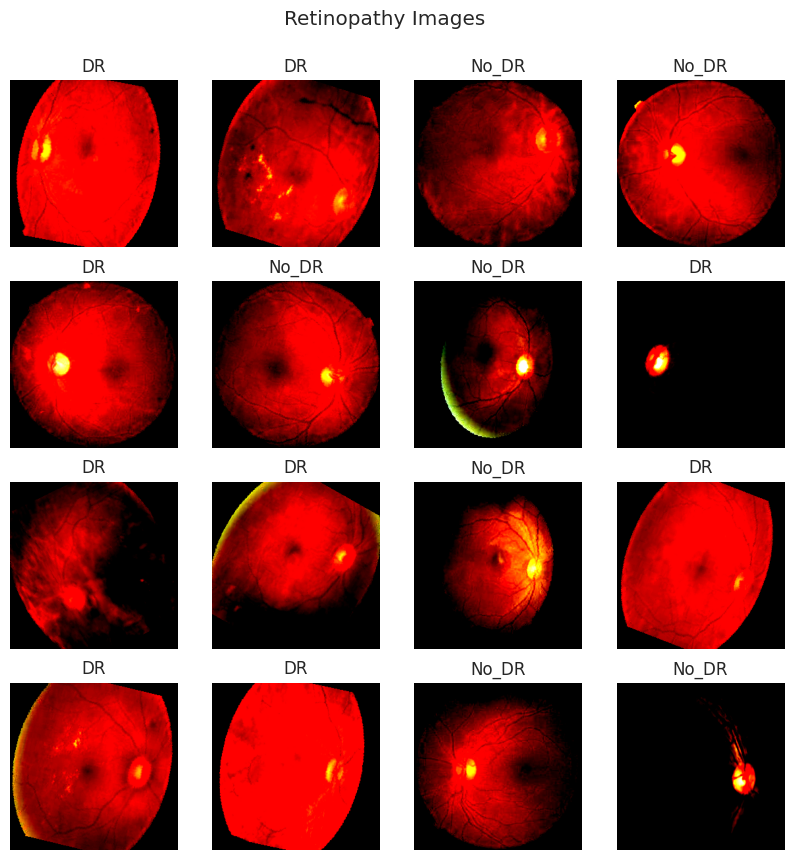

In [6]:
# Visualizing some images from Trainset
CLA_label = {
        0 : 'DR',
        1 : 'No_DR',
}
figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CLA_label[label])
    plt.axis("off")
    img_np = img.numpy().transpose((1, 2, 0))
    # Clip pixel values to [0, 1]
    img_valid_range = np.clip(img_np, 0, 1)
    plt.imshow(img_valid_range)
    plt.suptitle('Retinopathy Images', y=0.95)
plt.show()

## <b>5 <span style='color:#e61227'>|</span> Creating Dataloaders</b> 

In [7]:
# Import and load Train, Validation and Test set
batch_size = 64

train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle = True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle = True)

In [8]:
# Print shape of Dataset
for key, value in {'Training data': train_loader, "Validation data": val_loader}.items():
    for X, y in value:
        print(f"{key}:")
        print(f"Shape of X : {X.shape}")
        print(f"Shape of y: {y.shape} {y.dtype}\n")
        break

Training data:
Shape of X : torch.Size([64, 3, 255, 255])
Shape of y: torch.Size([64]) torch.int64

Validation data:
Shape of X : torch.Size([64, 3, 255, 255])
Shape of y: torch.Size([64]) torch.int64



## <b>6 <span style='color:#e61227'>|</span> Define Diabetic Retinopathy Classifier</b> 

In [9]:
'''This function can be useful in determining the output size of a convolutional layer,
given the input dimensions and the convolutional layer's parameters.'''

def findConv2dOutShape(hin, win, conv, pool=2):
    kernel_size = conv.kernel_size
    stride = conv.stride
    padding = conv.padding
    dilation = conv.dilation
 
    hout = np.floor((hin + 2 * padding[0] - dilation[0] * (kernel_size[0] - 1) - 1) / stride[0] + 1)
    wout = np.floor((win + 2 * padding[1] - dilation[1] * (kernel_size[1] - 1) - 1) / stride[1] + 1)
 
    if pool:
        hout /= pool
        wout /= pool
    return int(hout), int(wout)


In [10]:
# Define Architecture For Retinopathy Model
class CNN_Retino(nn.Module):
    def __init__(self, params):
        super(CNN_Retino, self).__init__()
 
        Cin, Hin, Win = params["shape_in"]
        init_f = params["initial_filters"]
        num_fc1 = params["num_fc1"]
        num_classes = params["num_classes"]
        self.dropout_rate = params["dropout_rate"]
 
        self.conv1 = nn.Conv2d(Cin, init_f, kernel_size=3)
        h, w = findConv2dOutShape(Hin, Win, self.conv1)
        self.conv2 = nn.Conv2d(init_f, 2 * init_f, kernel_size=3)
        h, w = findConv2dOutShape(h, w, self.conv2)
        self.conv3 = nn.Conv2d(2 * init_f, 4 * init_f, kernel_size=3)
        h, w = findConv2dOutShape(h, w, self.conv3)
        self.conv4 = nn.Conv2d(4 * init_f, 8 * init_f, kernel_size=3)
        h, w = findConv2dOutShape(h, w, self.conv4)
 
        self.num_flatten = h * w * 8 * init_f
        self.fc1 = nn.Linear(self.num_flatten, num_fc1)
        self.fc2 = nn.Linear(num_fc1, num_classes)
 
    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv4(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, self.num_flatten)
        X = F.relu(self.fc1(X))
        X = F.dropout(X, self.dropout_rate, training=self.training)  # <-- added training=self.training so dropout turns off in eval()
        X = self.fc2(X)
        return F.log_softmax(X, dim=1)

In [11]:
params_model = {
    "shape_in": (3, 255, 255),
    "initial_filters": 8,
    "num_fc1": 100,
    "dropout_rate": 0.15,
    "num_classes": 2
}
 
Retino_model = CNN_Retino(params_model)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Retino_model = Retino_model.to(device)

In [12]:
# Model Summary for CNN_Retino
summary(Retino_model, input_size=(3, 255, 255),device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 253, 253]             224
            Conv2d-2         [-1, 16, 124, 124]           1,168
            Conv2d-3           [-1, 32, 60, 60]           4,640
            Conv2d-4           [-1, 64, 28, 28]          18,496
            Linear-5                  [-1, 100]       1,254,500
            Linear-6                    [-1, 2]             202
Total params: 1,279,230
Trainable params: 1,279,230
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.74
Forward/backward pass size (MB): 7.05
Params size (MB): 4.88
Estimated Total Size (MB): 12.67
----------------------------------------------------------------


## <b>7 <span style='color:#e61227'>|</span> Loss Function Definition</b> 

In [13]:
loss_func = nn.NLLLoss(reduction="sum")


## <b>8 <span style='color:#e61227'>|</span> Optimiser Definition</b> 

In [14]:
opt = optim.Adam(Retino_model.parameters(), lr=1e-4)
lr_scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=20)

## <b>9 <span style='color:#e61227'>|</span> Training Model</b> 

In [15]:
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']

In [16]:
def metrics_batch(output, target):
    # counts number of correct predictions in a batch
    pred = output.argmax(dim=1, keepdim=True)
    corrects = pred.eq(target.view_as(pred)).sum().item()
    return corrects

In [17]:
def loss_batch(loss_func, output, target, opt=None):
    loss = loss_func(output, target)
    metric_b = metrics_batch(output, target)
 
    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()
 
    return loss.item(), metric_b

In [18]:
def loss_epoch(model, loss_func, dataset_dl, opt=None):
    running_loss = 0.0
    running_metric = 0.0
    len_data = len(dataset_dl.dataset)
 
    for xb, yb in dataset_dl:
        xb = xb.to(device)
        yb = yb.to(device)
        output = model(xb)
 
        loss_b, metric_b = loss_batch(loss_func, output, yb, opt)
 
        running_loss += loss_b
        if metric_b is not None:
            running_metric += metric_b
 
    loss = running_loss / len_data
    metric = running_metric / len_data
    return loss, metric

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>9.2 |</span></b>Training Function</b></p>
</div>

In [19]:
def train_val(model, params, verbose=True):  # <-- default verbose=True so you actually see epoch-wise data
    epochs = params["epochs"]
    loss_func = params["f_loss"]
    opt = params["optimiser"]
    train_dl = params["train"]
    val_dl = params["val"]
    lr_scheduler = params["lr_change"]
    weight_path = params["weight_path"]
 
    loss_history = {"train": [], "val": []}
    metric_history = {"train": [], "val": []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
 
    for epoch in tqdm(range(epochs)):
        current_lr = get_lr(opt)
 
        model.train()
        train_loss, train_metric = loss_epoch(model, loss_func, train_dl, opt)
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)
 
        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model, loss_func, val_dl)
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)
 
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), weight_path)
 
        lr_scheduler.step(val_loss)
        if current_lr != get_lr(opt):
            model.load_state_dict(best_model_wts)
 
        # ---- proper epoch-wise printout, every epoch ----
        print(f"Epoch {epoch+1}/{epochs} | lr={current_lr:.2e} | "
              f"train loss: {train_loss:.4f}, train acc: {100*train_metric:.2f}% | "
              f"val loss: {val_loss:.4f}, val acc: {100*val_metric:.2f}%")
 
    model.load_state_dict(best_model_wts)
    return model, loss_history, metric_history

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>9.3 |</span></b> Training Process </b></p>
</div>

In [20]:
params_train = {
    "train": train_loader, "val": val_loader,
    "epochs": 60,
    "optimiser": opt,                 # <-- reuse the same opt object (previously a second, disconnected optimiser was created)
    "lr_change": lr_scheduler,        # <-- reuse the same scheduler object, don't recreate it
    "f_loss": loss_func,
    "weight_path": "weights.pt",
}
 
Retino_model, loss_hist_m, metric_hist_m = train_val(Retino_model, params_train)
 

  2%|▏         | 1/60 [00:16<16:06, 16.39s/it]

Epoch 1/60 | lr=1.00e-04 | train loss: 0.6703, train acc: 64.26% | val loss: 0.6201, val acc: 64.03%


  3%|▎         | 2/60 [00:27<12:59, 13.43s/it]

Epoch 2/60 | lr=1.00e-04 | train loss: 0.5475, train acc: 74.95% | val loss: 0.4187, val acc: 86.25%


  5%|▌         | 3/60 [00:39<11:55, 12.55s/it]

...

Epoch 58/60 | lr=1.00e-04 | train loss: 0.1737, train acc: 93.50% | val loss: 0.1950, val acc: 92.66%


 98%|█████████▊| 59/60 [11:15<00:11, 11.58s/it]

Epoch 59/60 | lr=1.00e-04 | train loss: 0.1779, train acc: 93.26% | val loss: 0.1881, val acc: 92.84%


100%|██████████| 60/60 [11:27<00:00, 11.46s/it]

Epoch 60/60 | lr=1.00e-04 | train loss: 0.1776, train acc: 93.69% | val loss: 0.1915, val acc: 92.47%


## <b>10 <span style='color:#e61227'>|</span> Evaluation Metric Visualization</b>

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>10.1 |</span></b> Loss and Acccuracy Of Model </b></p>
</div>

<Axes: >

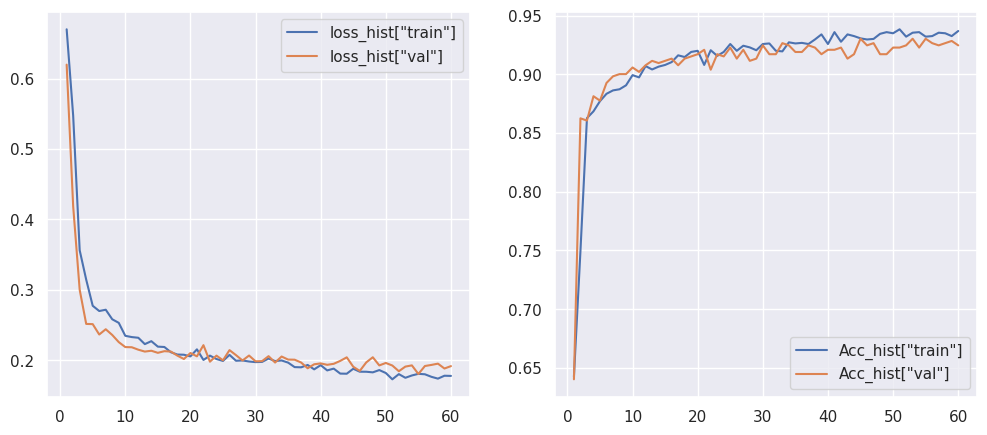

In [21]:
# Convergence History Plot
epochs=params_train["epochs"]
fig,ax = plt.subplots(1,2,figsize=(12,5))

sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist_m["train"],ax=ax[0],label='loss_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist_m["val"],ax=ax[0],label='loss_hist["val"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist_m["train"],ax=ax[1],label='Acc_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist_m["val"],ax=ax[1],label='Acc_hist["val"]')

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>10.2 |</span></b> Classification Report </b></p>
</div>

In [22]:
def true_and_pred(loader, model):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            output = model(images)                      # log-softmax output
            probs = torch.exp(output)                    # convert log-softmax -> probabilities
            pred = torch.argmax(probs, dim=1)
 
            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())      # probability of class "1" (No_DR) for ROC/AUC
 
    return np.array(y_true), np.array(y_pred), np.array(y_prob)



===== Train set — Classification Report =====
              precision    recall  f1-score   support

          DR       0.95      0.93      0.94      1050
       No_DR       0.93      0.95      0.94      1026

    accuracy                           0.94      2076
   macro avg       0.94      0.94      0.94      2076
weighted avg       0.94      0.94      0.94      2076

Train F1-score (class 'No_DR'): 0.9403


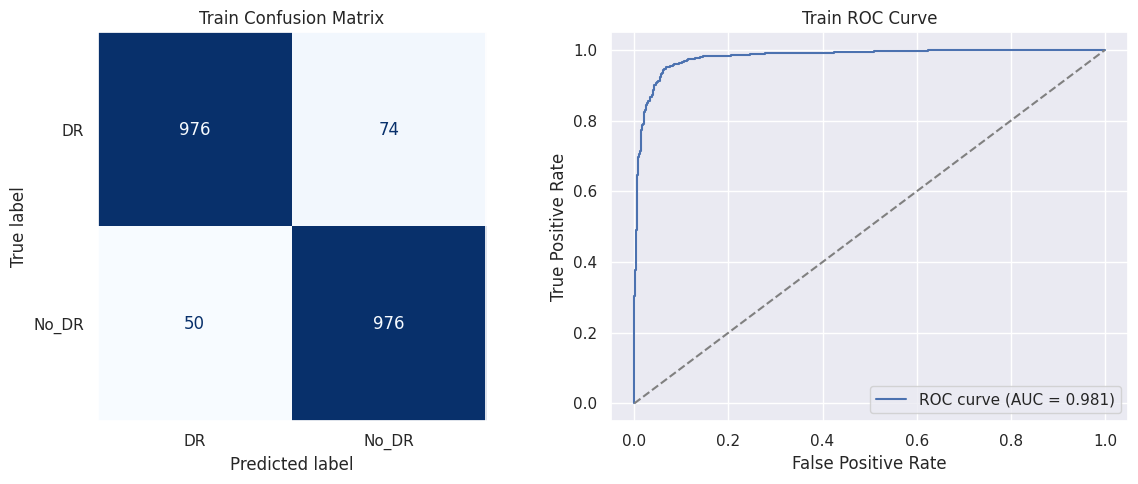


===== Validation set — Classification Report =====
              precision    recall  f1-score   support

          DR       0.93      0.92      0.93       245
       No_DR       0.93      0.94      0.94       286

    accuracy                           0.93       531
   macro avg       0.93      0.93      0.93       531
weighted avg       0.93      0.93      0.93       531

Validation F1-score (class 'No_DR'): 0.9375


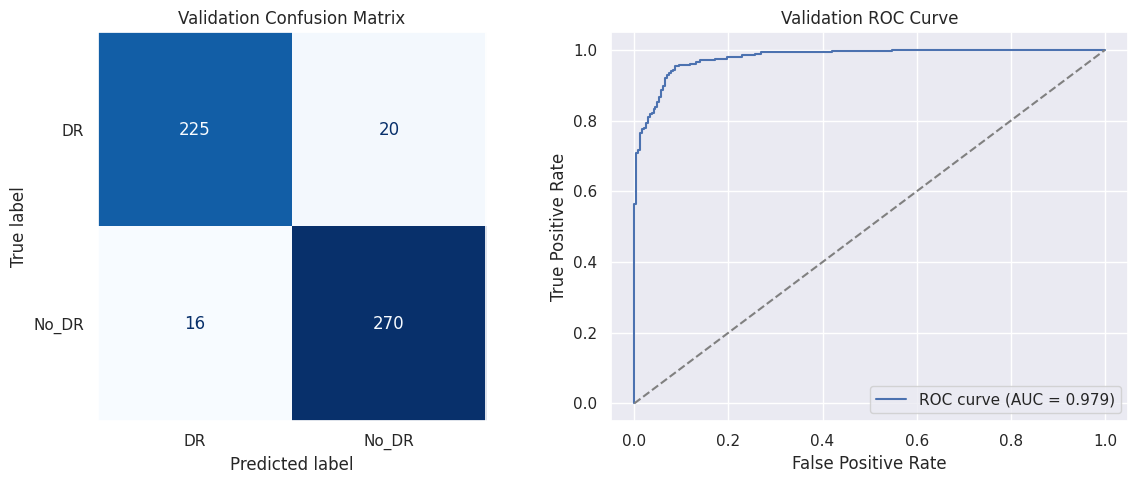

In [23]:
def true_and_pred(loader, model):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            output = model(images)                      # log-softmax output
            probs = torch.exp(output)                    # convert log-softmax -> probabilities
            pred = torch.argmax(probs, dim=1)
 
            y_true.extend(labels.numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(probs[:, 1].cpu().numpy())      # probability of class "1" (No_DR) for ROC/AUC
 
    return np.array(y_true), np.array(y_pred), np.array(y_prob)
 
 
def evaluate_and_plot(loader, model, split_name):
    y_true, y_pred, y_prob = true_and_pred(loader, model)
 
    print(f"\n===== {split_name} set — Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=["DR", "No_DR"]))
 
    f1 = f1_score(y_true, y_pred)
    print(f"{split_name} F1-score (class 'No_DR'): {f1:.4f}")
 
    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["DR", "No_DR"])
    disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"{split_name} Confusion Matrix")
    ax[0].grid(False)  # <-- turns off the seaborn darkgrid lines that were cutting through the matrix cells
 
    # ---- ROC Curve + AUC ----
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title(f"{split_name} ROC Curve")
    ax[1].legend(loc="lower right")
    plt.tight_layout()
    plt.show()
 
    return y_true, y_pred, y_prob, f1, roc_auc
 
 
# Run for all three splits
_ = evaluate_and_plot(train_loader, Retino_model, "Train")
_ = evaluate_and_plot(val_loader, Retino_model, "Validation")

In [24]:
# ----------------------------------------------------------
# Picture-wise evaluation — show actual test images with True vs Predicted labels
# ----------------------------------------------------------
# Since transforms.Normalize() was applied, we need to undo it before displaying,
# otherwise the images look color-shifted/washed out.
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
 
def denormalize(img_tensor):
    img = img_tensor.cpu() * STD + MEAN   # reverse the Normalize() transform
    img = img.clamp(0, 1)
    return img.numpy().transpose(1, 2, 0)  # CHW -> HWC for plt.imshow
 
 
def show_predictions_grid(loader, model, n_images=16, cols=4):
    model.eval()
    images_shown = 0
    rows = int(np.ceil(n_images / cols))
    fig = plt.figure(figsize=(cols * 3, rows * 3))
 
    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device, non_blocking=True)
            output = model(images_gpu)
            probs = torch.exp(output)
            preds = torch.argmax(probs, dim=1).cpu()
            confidences = probs.max(dim=1).values.cpu()
 
            for i in range(images.size(0)):
                if images_shown >= n_images:
                    break
 
                true_label = labels[i].item()
                pred_label = preds[i].item()
                conf = confidences[i].item()
                correct = (true_label == pred_label)
 
                ax = fig.add_subplot(rows, cols, images_shown + 1)
                ax.imshow(denormalize(images[i]))
                ax.axis("off")
                title = f"True: {CLA_label[true_label]}\nPred: {CLA_label[pred_label]} ({conf*100:.1f}%)"
                ax.set_title(title, color="green" if correct else "red", fontsize=10)
 
                images_shown += 1
            if images_shown >= n_images:
                break
 
    plt.suptitle("Test Set Predictions (green = correct, red = wrong)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
 
 
def show_misclassified_only(loader, model, max_images=16, cols=4):
    """Same as above but only shows the images the model got WRONG — most useful for debugging."""
    model.eval()
    wrong_images, wrong_true, wrong_pred, wrong_conf = [], [], [], []
 
    with torch.no_grad():
        for images, labels in loader:
            images_gpu = images.to(device, non_blocking=True)
            output = model(images_gpu)
            probs = torch.exp(output)
            preds = torch.argmax(probs, dim=1).cpu()
            confidences = probs.max(dim=1).values.cpu()
 
            for i in range(images.size(0)):
                if preds[i].item() != labels[i].item():
                    wrong_images.append(images[i])
                    wrong_true.append(labels[i].item())
                    wrong_pred.append(preds[i].item())
                    wrong_conf.append(confidences[i].item())
 
    n = min(len(wrong_images), max_images)
    if n == 0:
        print("No misclassified images found in this set.")
        return
 
    rows = int(np.ceil(n / cols))
    fig = plt.figure(figsize=(cols * 3, rows * 3))
    for idx in range(n):
        ax = fig.add_subplot(rows, cols, idx + 1)
        ax.imshow(denormalize(wrong_images[idx]))
        ax.axis("off")
        ax.set_title(f"True: {CLA_label[wrong_true[idx]]}\nPred: {CLA_label[wrong_pred[idx]]} "
                     f"({wrong_conf[idx]*100:.1f}%)", color="red", fontsize=10)
 
    plt.suptitle(f"Misclassified Images ({len(wrong_images)} total found)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

## <b>11<span style='color:#e61227'>|</span> Save Model </b>

In [25]:
torch.save(Retino_model, "Retino_model.pt")

## <b>13<span style='color:#e61227'>|</span> Detection Retinopathy By Real Image</b>


===== Test set — Classification Report =====
              precision    recall  f1-score   support

          DR       0.95      0.92      0.94       113
       No_DR       0.93      0.96      0.94       118

    accuracy                           0.94       231
   macro avg       0.94      0.94      0.94       231
weighted avg       0.94      0.94      0.94       231

Test F1-score (class 'No_DR'): 0.9417


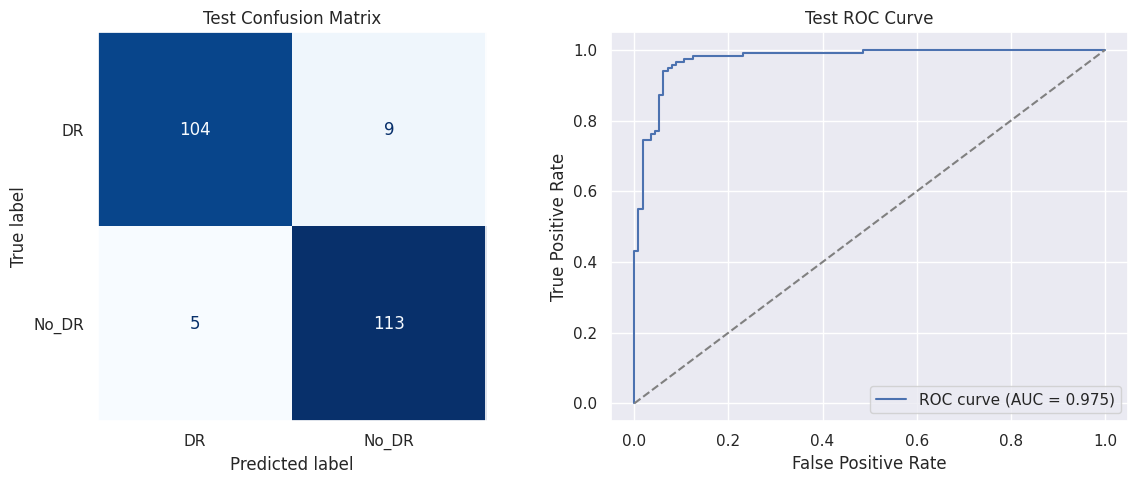

In [26]:
model = torch.load("Retino_model.pt", weights_only=False)  # <-- weights_only=False needed on newer torch versions for full-model pickles
model = model.to(device)
 
_ = evaluate_and_plot(test_loader, model, "Test")
 

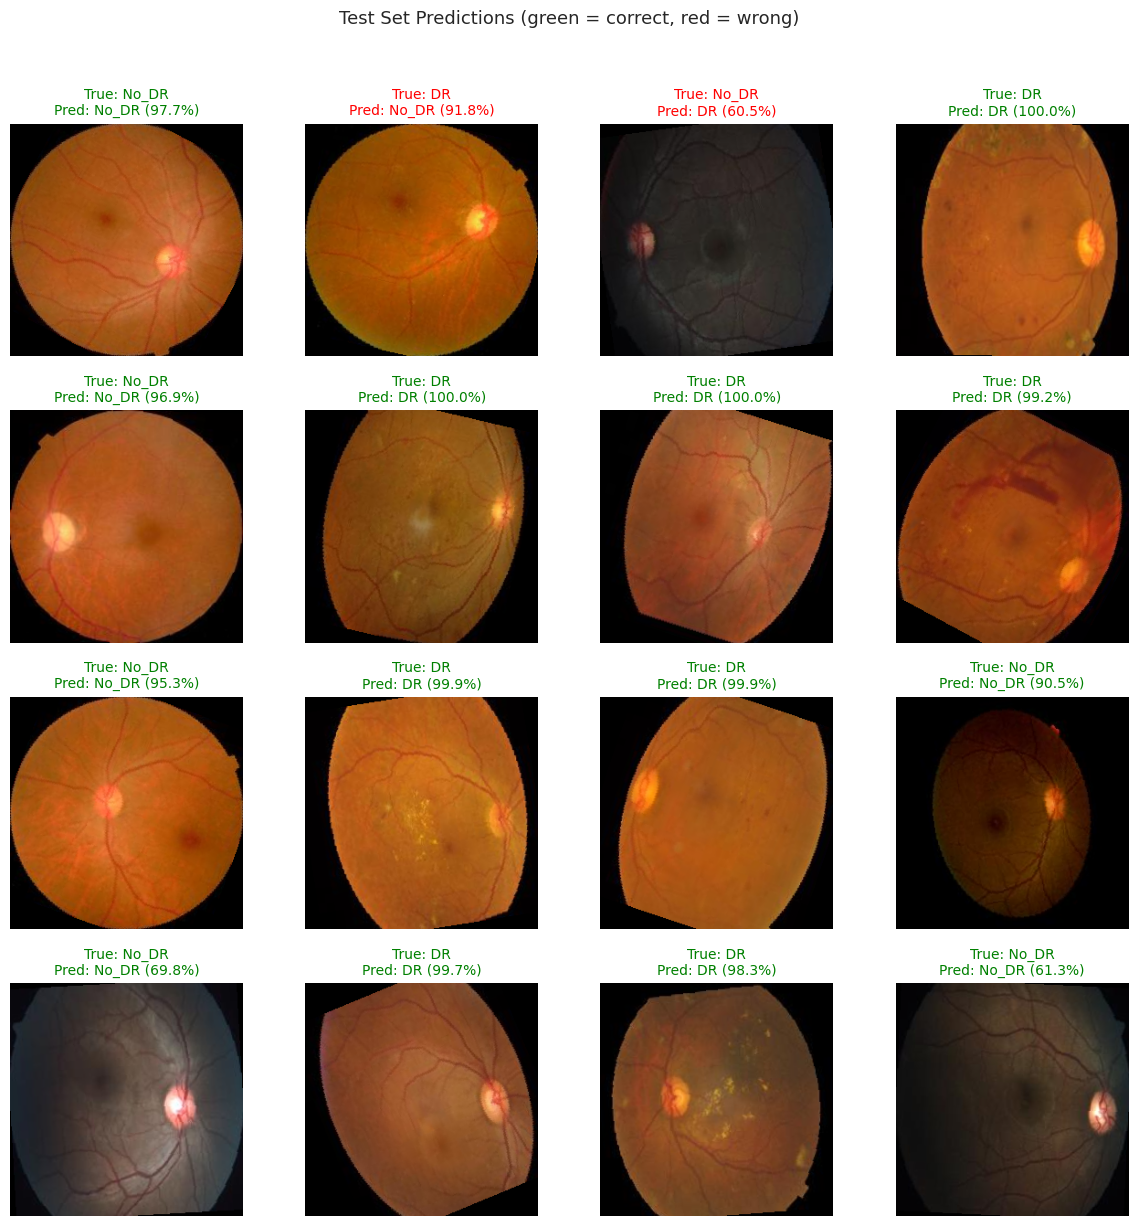

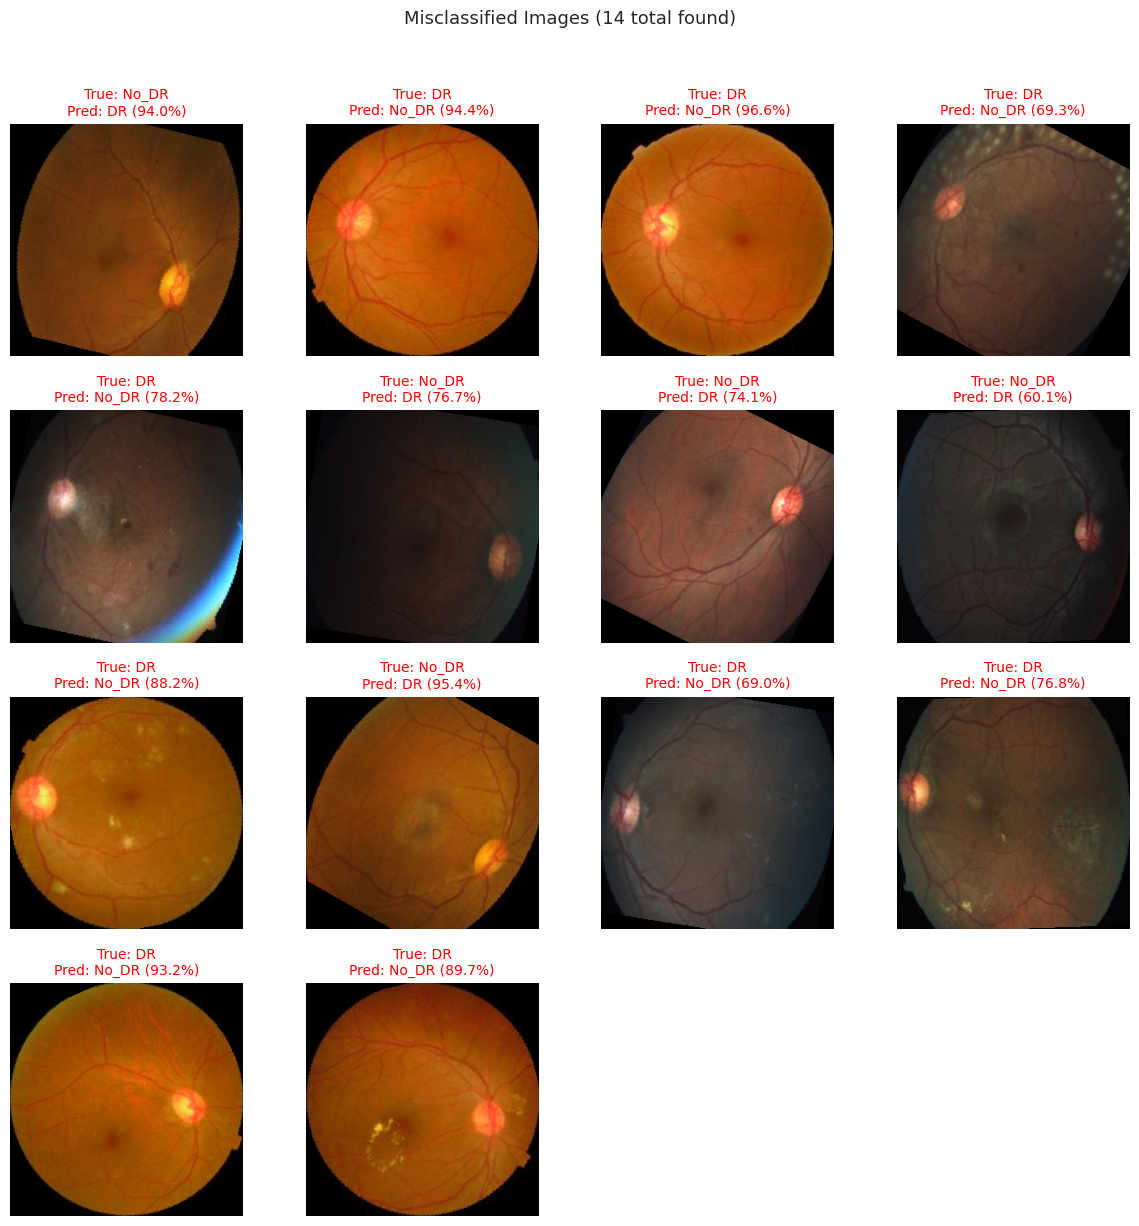

In [27]:
show_predictions_grid(test_loader, model, n_images=16, cols=4)   # random sample of predictions
show_misclassified_only(test_loader, model, max_images=16, cols=4)  # only the ones it got wrong
 


<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'></span></b> Thank you for taking the time to review my notebook. If you have any questions or criticisms, please kindly let me know in the comments section.</b></p>
</div>
